In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os

real_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/real"

print(os.listdir(real_path)[:5])

['id11_0004.mp4', 'id12_0003.mp4', 'id24_0008.mp4', 'id22_0009.mp4', 'id0_0007.mp4']


In [14]:
fake_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/fake"

print(os.listdir(fake_path)[:5])

['id0_id28_0007.mp4', 'id16_id26_0010.mp4', 'id0_id26_0008.mp4', 'id12_id10_0001.mp4', 'id0_id26_0002.mp4']


In [15]:
!pip install opencv-python tensorflow numpy matplotlib scikit-learn

In [16]:
import cv2

video_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/real/" + os.listdir(real_path)[0]

cap = cv2.VideoCapture(video_path)

success, frame = cap.read()

print("Video Loaded:", success)

cap.release()

Video Loaded: True


In [18]:
real_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/real"
fake_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/fake"

print("Real Videos:", len(os.listdir(real_path)))
print("Fake Videos:", len(os.listdir(fake_path)))

Real Videos: 100
Fake Videos: 100


In [20]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

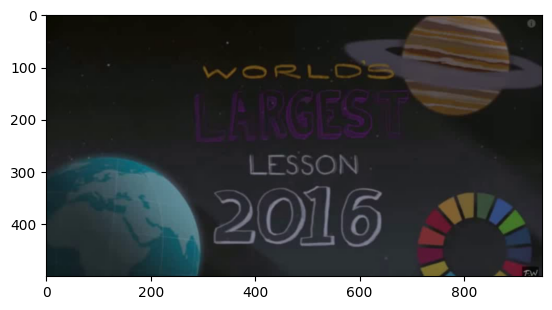

In [22]:
video_file = os.path.join(real_path, os.listdir(real_path)[0])
cap = cv2.VideoCapture(video_file)

success, frame = cap.read()

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame)
plt.show()

cap.release()

In [23]:
import os

os.makedirs("frames", exist_ok=True)

In [24]:
cap = cv2.VideoCapture(video_file)

count = 0

while True:

    success, frame = cap.read()

    if not success:
        break

    cv2.imwrite(
        f"frames/frame_{count}.jpg",
        frame
    )

    count += 1

cap.release()

print("Frames saved:", count)

Frames saved: 350


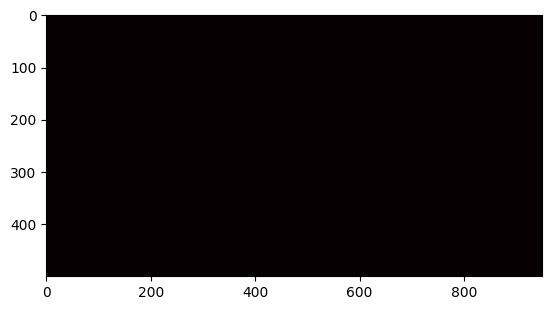

In [25]:
img = cv2.imread("frames/frame_10.jpg")

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img)
plt.show()

In [26]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

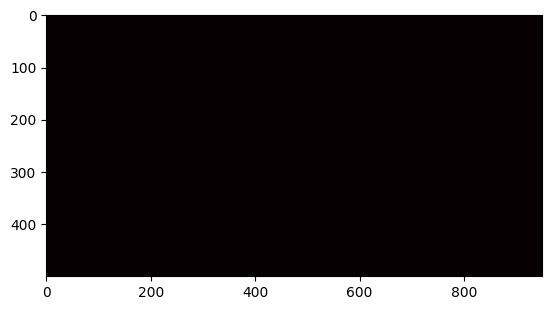

In [27]:
img = cv2.imread("frames/frame_10.jpg")

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

faces = face_detector.detectMultiScale(
    gray,
    1.1,
    4
)

for (x,y,w,h) in faces:

    cv2.rectangle(
        img,
        (x,y),
        (x+w,y+h),
        (255,0,0),
        2
    )

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img)
plt.show()

In [28]:
cap = cv2.VideoCapture(video_file)

success, frame = cap.read()

print("Success:", success)

if success:
    print("Frame shape:", frame.shape)

cap.release()

Success: True
Frame shape: (500, 950, 3)


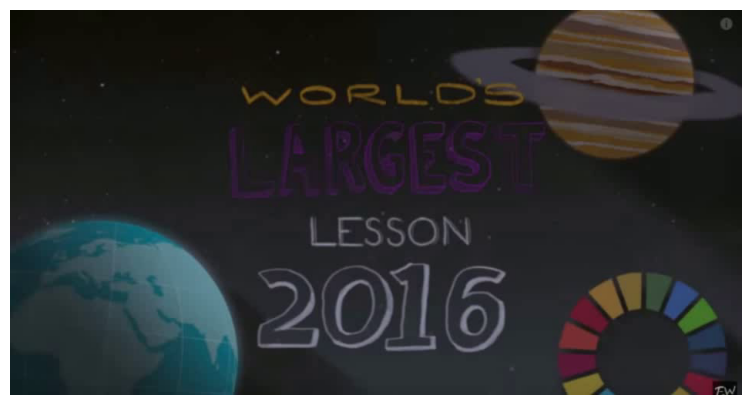

In [29]:
cap = cv2.VideoCapture(video_file)

success, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

cap.release()

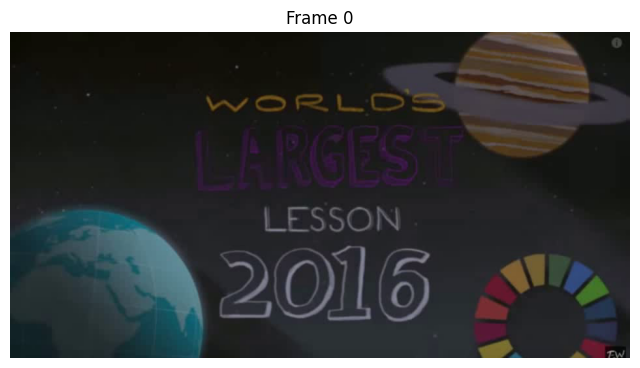

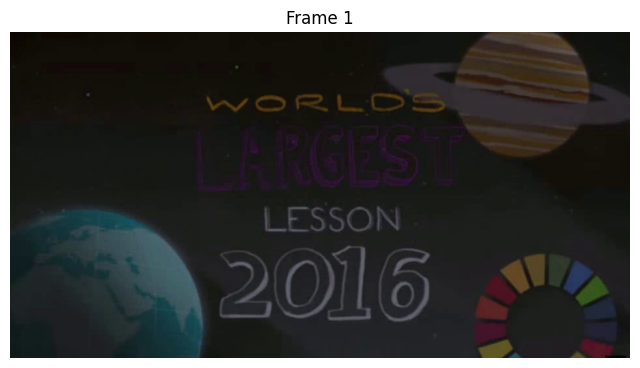

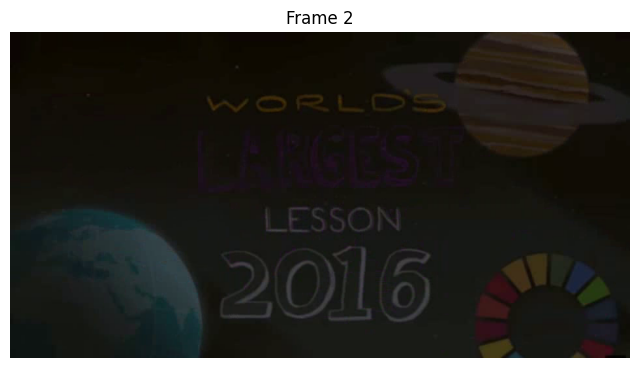

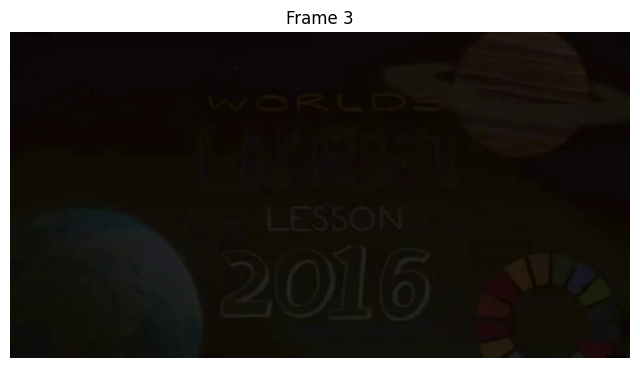

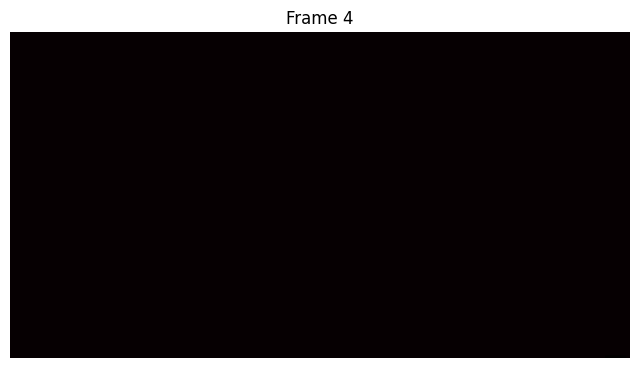

In [31]:
cap = cv2.VideoCapture(video_file)

for i in range(5):
    success, frame = cap.read()

    if success:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,10))
        plt.imshow(frame_rgb)
        plt.axis("off")
        plt.title(f"Frame {i}")
        plt.show()

cap.release()

In [32]:
print(video_file)

/content/drive/MyDrive/Deepfake_Detection/dataset/real/id11_0004.mp4


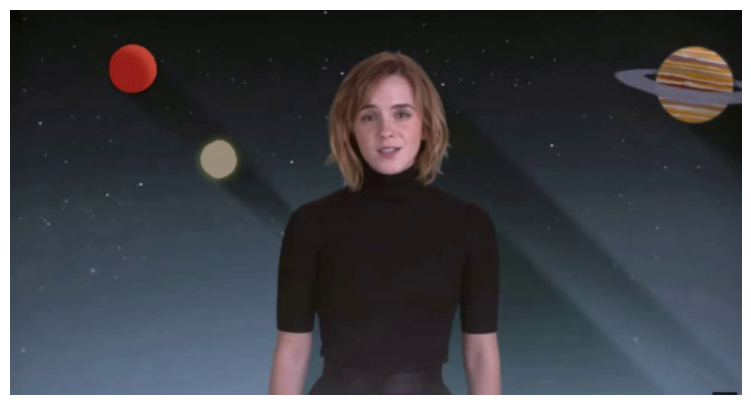

In [33]:
cap = cv2.VideoCapture(video_file)

for i in range(100):
    success, frame = cap.read()

    if not success:
        break

# Show frame around 100
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

cap.release()

Total Frames: 350


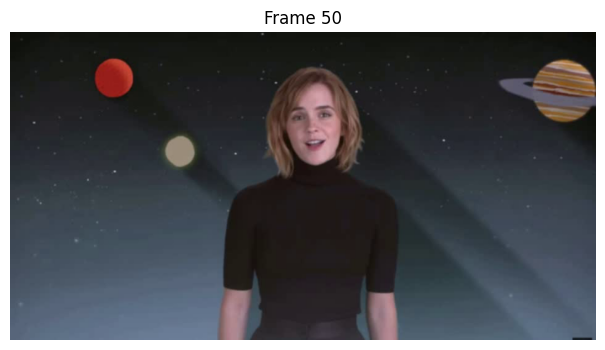

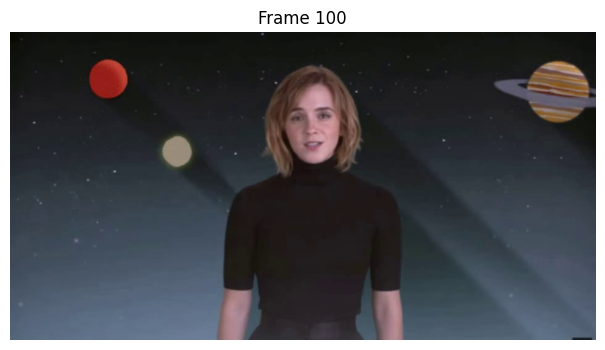

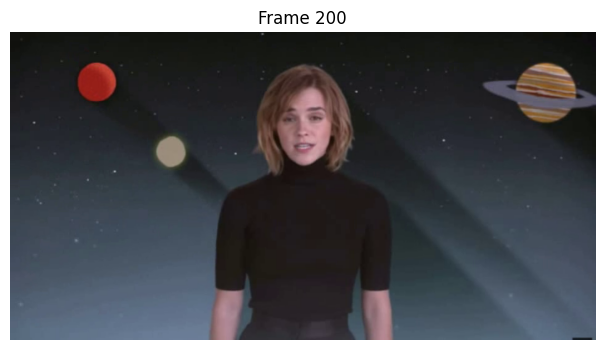

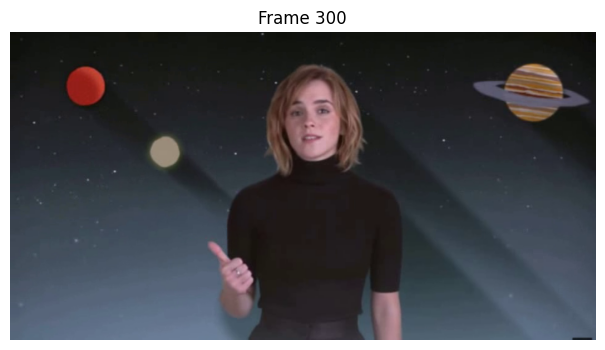

In [34]:
cap = cv2.VideoCapture(video_file)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Total Frames:", total_frames)

for pos in [50, 100, 200, 300]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, pos)

    success, frame = cap.read()

    if success:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,4))
        plt.imshow(frame_rgb)
        plt.title(f"Frame {pos}")
        plt.axis("off")
        plt.show()

cap.release()

In [35]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

img = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4
)

print("Faces detected:", len(faces))

Faces detected: 1


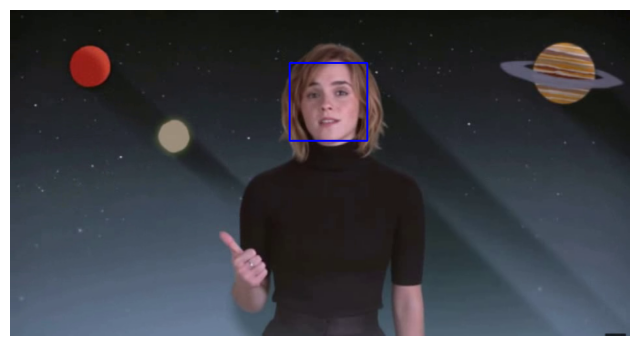

In [36]:
for (x, y, w, h) in faces:
    cv2.rectangle(
        img,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

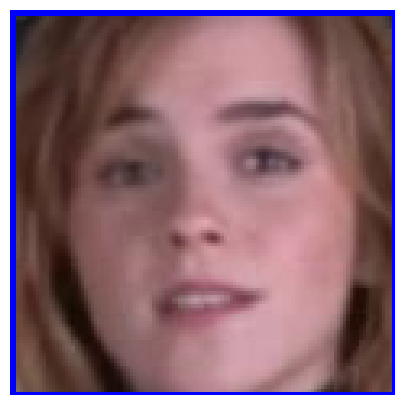

In [37]:
x, y, w, h = faces[0]

face = img_rgb[y:y+h, x:x+w]

plt.figure(figsize=(5,5))
plt.imshow(face)
plt.axis("off")
plt.show()

In [38]:
face = cv2.resize(face, (224, 224))

print(face.shape)

(224, 224, 3)


In [39]:
data = []
labels = []

In [55]:
real_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/real"
for video_name in os.listdir(real_path):

    video_file = os.path.join(real_path, video_name)

    cap = cv2.VideoCapture(video_file)

    frame_count = 0

    while True:

        success, frame = cap.read()

        if not success:
            break

        frame_count += 1

        # Take every 30th frame
        if frame_count % 30 != 0:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_detector.detectMultiScale(
            gray,
            1.1,
            4
        )

        for (x, y, w, h) in faces:

            face = frame[y:y+h, x:x+w]

            face = cv2.resize(face, (224,224))

            data.append(face)

            labels.append(0)

            break

    cap.release()

In [58]:
fake_path = "/content/drive/MyDrive/Deepfake_Detection/dataset/fake"
for video_name in os.listdir(fake_path):

    video_file = os.path.join(real_path, video_name)

    cap = cv2.VideoCapture(video_file)

    frame_count = 0

    while True:

        success, frame = cap.read()

        if not success:
            break

        frame_count += 1

        # Take every 30th frame
        if frame_count % 30 != 0:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_detector.detectMultiScale(
            gray,
            1.1,
            4
        )

        for (x, y, w, h) in faces:

            face = frame[y:y+h, x:x+w]

            face = cv2.resize(face, (224,224))

            data.append(face)

            labels.append(1)

            break

    cap.release()

In [59]:
X = np.array(data)

y = np.array(labels)

print(X.shape)
print(y.shape)

(2277, 224, 224, 3)
(2277,)


In [60]:
X = X / 255.0

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1821, 224, 224, 3)
(456, 224, 224, 3)


In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D())

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D())

model.add(Flatten())

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [64]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.9478 - loss: 0.3283 - val_accuracy: 0.9561 - val_loss: 0.1453
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9572 - loss: 0.1682 - val_accuracy: 0.9561 - val_loss: 0.1391
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9627 - loss: 0.1355 - val_accuracy: 0.9583 - val_loss: 0.1419
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9638 - loss: 0.1288 - val_accuracy: 0.9693 - val_loss: 0.1222
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9681 - loss: 0.0994 - val_accuracy: 0.9715 - val_loss: 0.1182
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9720 - loss: 0.0995 - val_accuracy: 0.9803 - val_loss: 0.1010
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9720 - loss: 0.0987 - val_accuracy: 0.9803 - val_loss: 0.0977
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9791 - loss: 0.0756 - val_accu

In [74]:
model.save('deepfake_model1234.h5')

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
prediction = model.predict(X_test[:1])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[3.472511e-06]]


In [76]:
if prediction[0][0] > 0.5:
    print("Deepfake Video")
else:
    print("Real Video")

Real Video


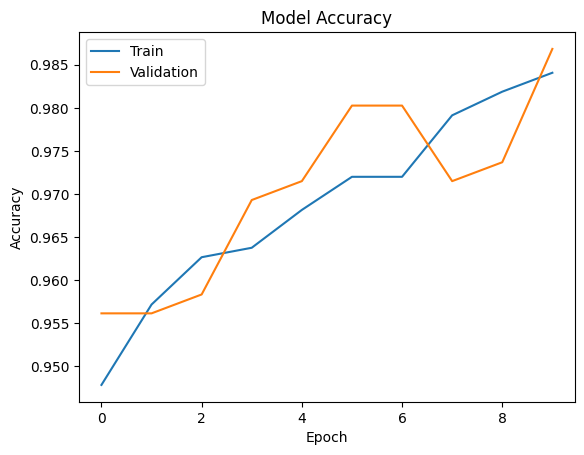

In [77]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])

plt.show()

In [78]:
import os
print(os.listdir())

['.config', 'frames', 'deepfake_model1234.h5', 'deepfake_model.h5', 'drive', 'sample_data']


In [79]:
from google.colab import files

files.download("deepfake_model1234.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
!pip install gradio

In [88]:
import gradio as gr
import cv2
import numpy as np
from tensorflow.keras.models import load_model

In [87]:
model = load_model("deepfake_model1234.h5")

In [89]:
def predict_video(video_path):

    cap = cv2.VideoCapture(video_path)

    success, frame = cap.read()

    cap.release()

    if not success:
        return "Cannot read video"

    face_detector = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        1.1,
        4
    )

    if len(faces) == 0:
        return "No Face Detected"

    x, y, w, h = faces[0]

    face = frame[y:y+h, x:x+w]

    face = cv2.resize(face, (224,224))

    face = face / 255.0

    face = np.expand_dims(face, axis=0)

    prediction = model.predict(face)

    if prediction[0][0] > 0.5:
        return "Fake Video"
    else:
        return "Real Video"

In [90]:
app = gr.Interface(
    fn=predict_video,
    inputs=gr.File(type="filepath"),
    outputs="text",
    title="Deepfake Video Detection"
)

In [91]:
app.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1b9994f81c61d113d5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://80b8905c6879de7c3e.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://1b9994f81c61d113d5.gradio.live
